<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

iris=load_iris()
# 넘파이 데이터 세트를 판다스 DataFrame으로 변환
columns = ['sepal_length','sepal_width','petal_length','petal_width']
iris_df = pd.DataFrame(iris.data,columns=columns)
iris_df['target']=iris.target
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


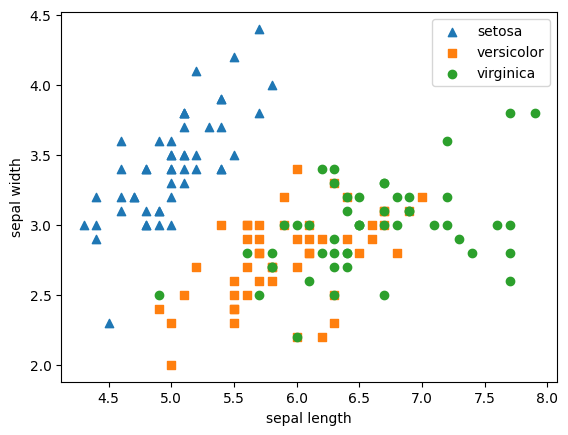

In [4]:
# 품종에 따라 원본 붓꽃 데이터 세트가 어떻게 분포돼 있는지 2차원으로 시각화
# setosa 는 세모, vericolor는 네모, virginica는 동그라미로 표현
markers=['^','s','o']

# setosa의 target 값 0, versicolor는 1, virginica는 2, 각 target 별로 다른 모양으로 산점도로 표시
for i,marker in enumerate(markers):
  x_axis_data=iris_df[iris_df['target']==i]['sepal_length']
  y_axis_data = iris_df[iris_df['target']==i]['sepal_width']
  plt.scatter(x_axis_data,y_axis_data,marker=marker,label=iris.target_names[i])

plt.legend()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.show()

Setosa 품종의 경우 sepal width가 3.0보다 크고, sepal length가 6.0 이하인 곳에 일정하게 분포돼 있습니다. Versicolor와 virginica의 경우는 sepal width와 sepal length 조건만으로는 분류가 어려운 복잡한 조건임을 알 수 있습니다.

PCA로 4개의 속성을 2개로 압축한 뒤 앞의 예제와 비슷하게 2개의 PCA 속성으로 붓꽃 데이터의 품종 분포를 2차원으로 시각화해 보겟습니다.

In [5]:
from sklearn.preprocessing import StandardScaler

# Target 값을 제외한 모든 속성 값을 StandardScaler를 이용해 표준 정규 분포를 가지는 값들로 변환
iris_scaled = StandardScaler().fit_transform(iris_df.iloc[:,:-1])

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

# fit()과 transform()을 호출해 PCA 변환 데이터 반환
pca.fit(iris_scaled)
iris_pca=pca.transform(iris_scaled)
print(iris_pca.shape)


(150, 2)


In [7]:
# PCA 변환된 데이터의 칼럼명을 각각 pca_component_1,pca_component_2로 명명
pca_columns=['pca_component_1','pca_component_2']
iris_df_pca = pd.DataFrame(iris_pca,columns=pca_columns)
iris_df_pca ['target']=iris.target
iris_df_pca.head(3)


,pca_component_1,pca_component_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0


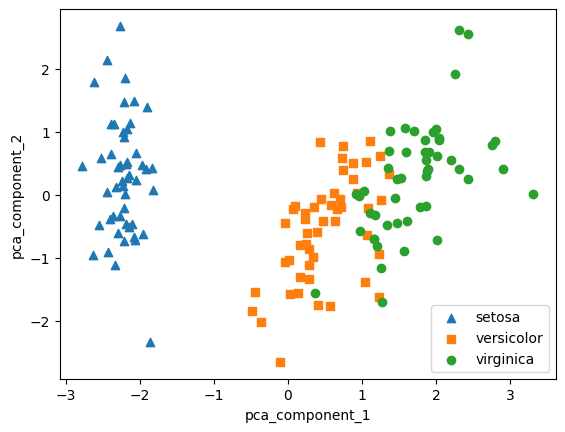

In [10]:
# setosa를 세모, versicolor를 네모, virginica를 동그라미로 표시
markers=['^','s','o']

#pca_component_1을 x축,pc_component_2를 y축으로 scatter plot 수행
for i,marker in enumerate(markers):
  x_axis_data = iris_df_pca[iris_df_pca['target']==i]['pca_component_1']
  y_axis_data = iris_df_pca[iris_df_pca['target']==i]['pca_component_2']
  plt.scatter(x_axis_data,y_axis_data,marker=marker,label=iris.target_names[i])

plt.legend()
plt.xlabel('pca_component_1')
plt.ylabel('pca_component_2')
plt.show()

PCA로 변환한 후에도 pca_component_1 축을 기반으로 Setosa 품종은 명확하게 구분이 가능합니다. Versicolor와 Virginica는 pca_component_1 축을 기반으로 서로 겹치는 부분이 일부 존재하지만, 비교적 잘 구분됐습니다. 이는 PCA의 첫 번째 새로운 축인 pca_component_1이 원본 데이터의 변동성을 잘 반영했기 때문입니다. PCA Component 별로 원본 데이터의 변동성을 얼마나 반영하고 있는지 알아보겠습니다.

PCA 변환을 수행한 PCA 객체의 explained_variance_ratio_ 속성은 전체 변동성에서 개별 PCA 컴포넘트별로 차지하는 변동성 비율을 제공하고 있습니다.

In [11]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


첫 번째 PCA 변환 요소인 pca_component_1이 전체 변동성의 약 72.9% 를 차지하며, 두 번인 pca_component_2가 약 22.8%를 차지합니다. 따라서 PCA를 2개 요소로만 변환해도 원본 데이터의 변동성을 95% 설명할 수 있습니다.

In [15]:
# 원본 데이터 세트 예측 정확도
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rcf = RandomForestClassifier(random_state=156)
scores = cross_val_score(rcf,iris.data,iris.target,scoring='accuracy',cv=3)
print(f'원본 데이터 교차 검증 개별 정확도:{scores}')
print(f'원본 데이터 평균 정확도:{np.mean(scores)}')

원본 데이터 교차 검증 개별 정확도:[0.98 0.94 0.96]
원본 데이터 평균 정확도:0.96


In [16]:
# pca 적용 데이터 세트 예측 정확도
pca_X = iris_df_pca[['pca_component_1','pca_component_2']]
scores_pca = cross_val_score(rcf,pca_X,iris.target,scoring='accuracy',cv=3)
print(f'PCA 변환 데이터 교차 검증 개별 정확도:{scores_pca}')
print(f'PCA 변환 데이터 평균 정확도:{np.mean(scores_pca)}')

PCA 변환 데이터 교차 검증 개별 정확도:[0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도:0.88


붓꽃 데이터의 경우 pca를 적용하여 4개의 속성이 2개의 변환 속성으로 감소하면서 예측 성능의 정확도가 원본 데이터 대비 약 8% 하락했습니다.

8%의 하락은 비교적 큰 성능 수치의 감소지만, 4개의 속성이 2개로, 속성 개수가 50% 감소한 것을 고려한다면 PCA 변환 후에도 원본 데이터의 특성을 상당 부분 유지하고 있음을 알 수 있습니다.